In [41]:
include("TrenberthCallbacks.jl")  # loads module into Main
using .TrenberthCallbacks   

In [46]:
using SpeedyWeather, Dates

spectral_grid = SpectralGrid()
model = PrimitiveWetModel(spectral_grid)

# Explicitly add diagnostics your callback expects
add!(model, SpeedyWeather.RadiationOutput()...)
add!(model, SpeedyWeather.SurfaceFluxesOutput()...)

cb = TrenberthCallbacks.TrenberthCallback(schedule=Schedule(every=Hour(12)))
add!(model.callbacks, :trenberth => cb)

sim = initialize!(model)
run!(sim, period=Day(10))


┌ Info: Could not determine nsteps, using dynamic push mode
└ @ Main.TrenberthCallbacks c:\Users\Hannah\OneDrive - Nexus365\Documents\group_project\speedyweather_trenberth_diagram\TrenberthCallbacks.jl:121
┌ Info: Finalizing TrenberthCallback: computing means
└ @ Main.TrenberthCallbacks c:\Users\Hannah\OneDrive - Nexus365\Documents\group_project\speedyweather_trenberth_diagram\TrenberthCallbacks.jl:177
┌ Info: Mean LW_net_sfc over simulation: -229.76765877859933
└ @ Main.TrenberthCallbacks c:\Users\Hannah\OneDrive - Nexus365\Documents\group_project\speedyweather_trenberth_diagram\TrenberthCallbacks.jl:180
┌ Info: Mean OLR over simulation: 312.2541198730469
└ @ Main.TrenberthCallbacks c:\Users\Hannah\OneDrive - Nexus365\Documents\group_project\speedyweather_trenberth_diagram\TrenberthCallbacks.jl:180
┌ Info: Mean SSRD over simulation: 325.0038800920759
└ @ Main.TrenberthCallbacks c:\Users\Hannah\OneDrive - Nexus365\Documents\group_project\speedyweather_trenberth_diagram\TrenberthCallbac

In [43]:
@show keys(cb.data)
@show length(cb.times)
@show size(cb.data[:LHF])

keys(cb.data) = [:LW_net_sfc, :OLR, :SSRD, :SLRD, :SHF, :SSRU, :SLRU, :LHF, :albedo, :SW_net_sfc, :OSR, :surface_net]
length(cb.times) = 21
size(cb.data[:LHF]) = (21,)


(21,)

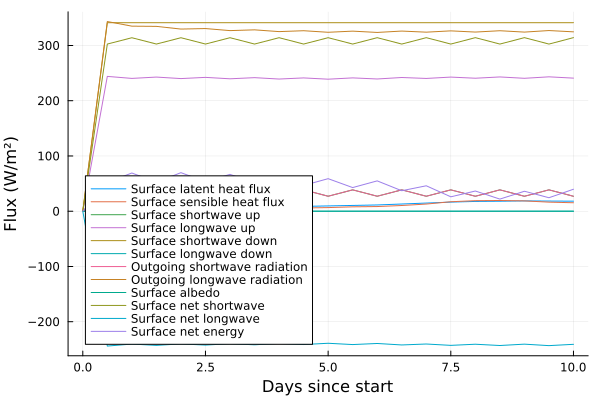

In [69]:
using Plots

# Obtain the time
t = cb.times
t_days = t ./ (60 * 60 * 24)

# Obtain the fluxes
lhf = cb.data[:LHF]
shf = cb.data[:SHF]
ssru = cb.data[:SSRU]
slru = cb.data[:SLRU]
ssrd = cb.data[:SSRD]
slrd = cb.data[:SLRD]
osr = cb.data[:OSR]
olr = cb.data[:OLR]
alb = cb.data[:albedo]
sns = cb.data[:SW_net_sfc]
snl = cb.data[:LW_net_sfc]
sne = cb.data[:surface_net]

### Plot the fluxes ###

# First plot
plot(t_days, lhf,
     xlabel = "Days since start",
     ylabel = "Flux (W/m²)",
     label  = "Surface latent heat flux")

# Add others to the same plot
plot!(t_days, shf,  label = "Surface sensible heat flux")
plot!(t_days, ssru, label = "Surface shortwave up")
plot!(t_days, slru, label = "Surface longwave up")
plot!(t_days, ssrd, label = "Surface shortwave down")
plot!(t_days, slrd, label = "Surface longwave down")
plot!(t_days, osr, label = "Outgoing shortwave radiation")
plot!(t_days, olr, label = "Outgoing longwave radiation")
plot!(t_days, alb, label = "Surface albedo")
plot!(t_days, sns, label = "Surface net shortwave")
plot!(t_days, snl, label = "Surface net longwave")
plot!(t_days, sne, label = "Surface net energy")


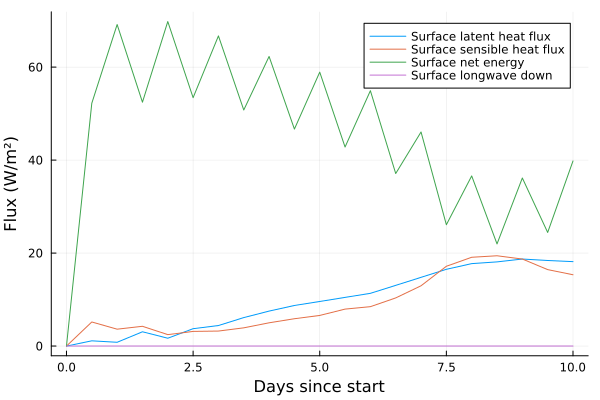

In [78]:
# Splitting up plot to see fluxes better

# Plot 1 - surface sensible heat + latent heat flux + albedo
plot(t_days, lhf, xlabel = "Days since start", ylabel = "Flux (W/m²)", label  = "Surface latent heat flux")
plot!(t_days, shf,  label = "Surface sensible heat flux")
plot!(t_days, sne, label = "Surface net energy")
plot!(t_days, slrd, label = "Surface longwave down")


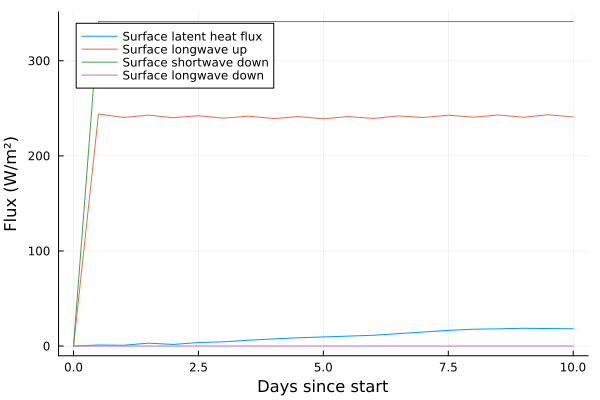

In [77]:
# Plot 2 - 

plot(t_days, lhf, xlabel = "Days since start", ylabel = "Flux (W/m²)", label  = "Surface latent heat flux")
plot!(t_days, slru, label = "Surface longwave up")
plot!(t_days, ssrd, label = "Surface shortwave down")
plot!(t_days, slrd, label = "Surface longwave down")


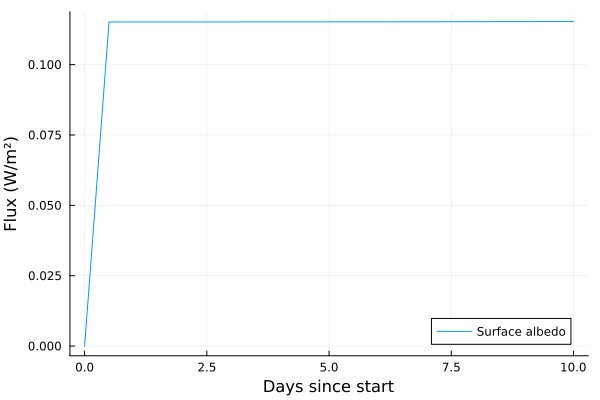

In [ ]:
# Plot 4 - surface albedo
plot(t_days, alb, xlabel = "Days since start", ylabel = "Flux (W/m²)", label  = "Surface albedo")